In [3]:
import pandas as pd

**loading the dataset**

In [4]:
df = pd.read_csv(r"datasets/netflix_titles.csv")

#### understanding the dataset

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [4]:
df.shape

(7787, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   str  
 10  listed_in     7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(1), str(11)
memory usage: 730.2 KB


#### finding missing values

In [6]:
df.isna().any()

show_id         False
type            False
title           False
director         True
cast             True
country          True
date_added       True
release_year    False
rating           True
duration        False
listed_in       False
description     False
dtype: bool

**ranking columns based on missing values**

In [7]:
# Calculate the percentage of missing values per column and sort them descending
missing_percentage = df.isnull().mean() * 100
missing_ranked = missing_percentage.sort_values(ascending=False)

# Print the ranked list
print("--- Columns Ranked by Missingness (%) ---")
print(missing_ranked)

--- Columns Ranked by Missingness (%) ---
director        30.679337
cast             9.220496
country          6.510851
date_added       0.128419
rating           0.089893
title            0.000000
show_id          0.000000
type             0.000000
release_year     0.000000
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64


### handling missing data


##### filling the director column
filling missing in director column with "unknown" because this column will help us deciding director's shows are going on trend 

In [8]:
df["director"] = df["director"].fillna(value="unknown")

##### filling cast column
also filling this with unknown because it can also help us analyze which show can go on trend if have particular people in cast

In [9]:
df["cast"] = df["cast"].fillna(value="unknown")

##### dropping all the rows which have country null

In [10]:
df = df.dropna(subset=["country"])

##### dropping rating and date_added rows
because i want pristine dataset for modeling and don't want to introduce any artificial or duplicated dates/ratings.

In [11]:
df = df.dropna(subset=["rating", "date_added"])

##### seeing duplicates
some columns can have duplicate values because of many reason one of them may like many movie might be directed by one same director, like
- type
- director
- cast
- country 
- rating 
- duration
- listed_in

but some columns must be unique so that we can have distinction, like
- title
- description

In [12]:
df[df.duplicated(subset="duration", keep=False)].sort_values(by="duration")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
3226,s3227,TV Show,JU-ON: Origins,unknown,"Yoshiyoshi Arakawa, Yuina Kuroshima, Ririka, K...",Japan,"July 3, 2020",2020,TV-MA,1 Season,"International TV Shows, TV Horror, TV Mysteries",A paranormal researcher searches obsessively f...
4938,s4939,TV Show,Power Rangers Operation Overdrive,unknown,"James Maclurcan, Caitlin Murphy, Samuell Benta...","United States, New Zealand, Japan","January 1, 2016",2007,TV-Y7,1 Season,Kids' TV,To keep powerful jewels from falling into the ...
4937,s4938,TV Show,Power Rangers Ninja Storm,unknown,"Pua Magasiva, Sally Martin, Glenn McMillan, Ad...","United States, New Zealand","January 1, 2016",2003,TV-Y7,1 Season,Kids' TV,When the elite warriors from the Wind Ninja Ac...
4935,s4936,TV Show,Power Rangers Mystic Force,unknown,"Firass Dirani, Angie Diaz, Richard Brancatisan...",United States,"January 1, 2016",2006,TV-Y7,1 Season,Kids' TV,"When the wicked Undead Army is unleashed, sorc..."
1335,s1336,TV Show,Children of the Whales,unknown,"Natsuki Hanae, Manaka Iwami, Yuuichirou Umehar...",Japan,"March 13, 2018",2017,TV-14,1 Season,"Anime Series, International TV Shows","As a magic wielder, young archivist Chakuro kn..."
...,...,...,...,...,...,...,...,...,...,...,...,...
423,s424,Movie,"All's Well, End's Well (2009)",Vincent Kok,"Louis Koo, Sandra Ng Kwan Yue, Raymond Wong, R...",Hong Kong,"November 9, 2018",2009,TV-14,99 min,"Comedies, International Movies, Romantic Movies",Bound by a family rule that forbids him from m...
1293,s1294,Movie,Chasing Trane,John Scheinfeld,"Denzel Washington, Bill Clinton, Ravi Coltrane...",United States,"November 13, 2017",2016,TV-PG,99 min,"Documentaries, Music & Musicals","Featuring interviews, insights and archival fo..."
4039,s4040,Movie,Mercenary,Sacha Wolff,"Toki Pilioko, Iliana Zabeth, Mikaele Tuugahala...",France,"December 4, 2016",2016,TV-MA,99 min,"Dramas, International Movies, Sports Movies",When he defies his cruel father and leaves New...
4107,s4108,Movie,MindGamers,Andrew Goth,"Tom Payne, Melia Kreiling, Antonia Campbell-Hu...",Austria,"January 15, 2020",2017,R,99 min,"International Movies, Sci-Fi & Fantasy, Thrillers",Brilliant young students discover a breakthrou...


In [13]:
df[df.duplicated()]   # <---- if nothing shows up means no duplicate row exist

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


##### Feature Understanding

In [14]:
df["country"].head(50)

0                             Brazil
1                             Mexico
2                          Singapore
3                      United States
4                      United States
5                             Turkey
6                              Egypt
7                      United States
8                              India
9                              India
10                     United States
11             Poland, United States
12                            Mexico
13                          Thailand
14                     United States
15                           Nigeria
17    Norway, Iceland, United States
18                             India
19                    United Kingdom
20                             India
21                             India
22                             India
23                             India
24                             Japan
25                     United States
26                     United States
27                       South Korea
2

#### Univariate Analysis

##### analyzing type column
In **type column**
movies are more common than TV shows


In [15]:
df[df["type"].str.contains("Movie")]["type"].count()

np.int64(5143)

##### analyzing rating column
checking which type of audience Netflix target more based on the rating according to the given dataset

In [16]:
# All Younger children under 7
under_7 = df[
    df["rating"].isin(["TV-Y", "TV-G", "G"])
]["rating"].count()

In [17]:
# children above 7+ 
above_7 = df[
    df["rating"].isin(["PG", "TV-Y7"])
]["rating"].count()

In [18]:
# older children 10+
above_10 = df[
    df["rating"].isin(["TV-Y7-FV", "TV-PG"])
]["rating"].count()

In [19]:
# teens 13+
above_13 = df[
    df["rating"].isin(["PG-13", "TV-14"])
]["rating"].count()

In [20]:
# older teens 16+ & adults 18+
adults = df[
    df["rating"].isin(["TV-MA", "R", "NC-17"])
]["rating"].count()

In [21]:
# for all ages
ur = df[
    df["rating"].isin(["UR"])
]["rating"].count()

In [22]:
# not rated 
nr = df[
    df["rating"].isin(["NR"])
]["rating"].count()


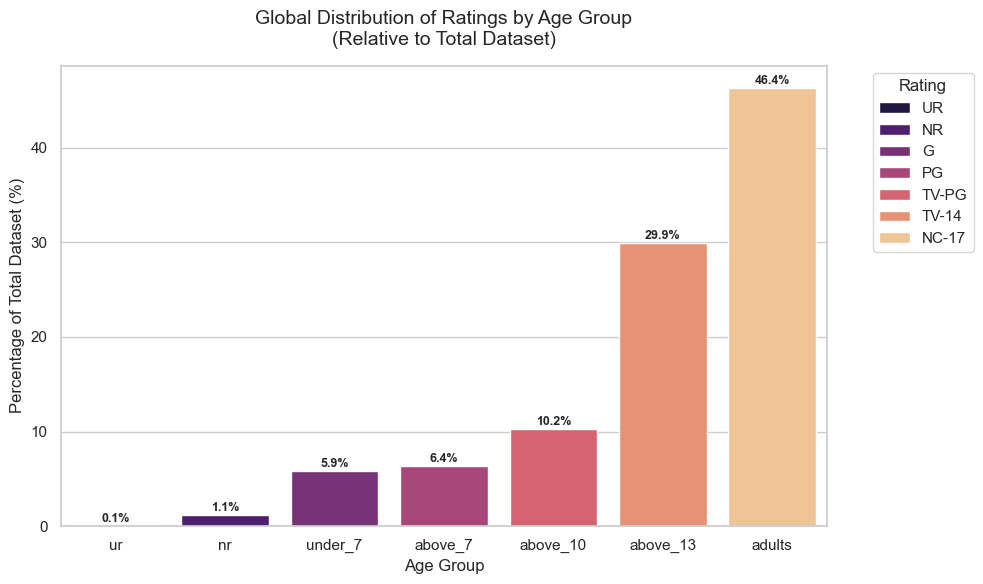

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "age_group": [
        "ur",
        "nr",
        "under_7",
        "above_7",
        "above_10",
        "above_13",
        "adults",
    ],  # age brackets
    "rating": [
        "UR",
        "NR",
        "G",
        "PG",
        "TV-PG",
        "TV-14",
        "NC-17",
    ],  # The specific ratings
    "count": [
        ur,
        nr,
        under_7,
        above_7,
        above_10,
        above_13,
        adults,
    ],  # manual counts for each pair
}

df_counts = pd.DataFrame(data)

total_dataset_count = df_counts["count"].sum()
df_counts["percentage"] = (df_counts["count"] / total_dataset_count) * 100

# Create the plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_counts,
    x="age_group",
    y="percentage",
    hue="rating",
    palette="magma",  # A clean, high-contrast color palette
)

# Stamp the percentages on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
        )

# Labels and Titles
plt.title(
    "Global Distribution of Ratings by Age Group\n(Relative to Total Dataset)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Percentage of Total Dataset (%)", fontsize=12)
plt.legend(title="Rating", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

##### analyzing release year

In [24]:
df.sort_values(by="release_year", ascending=True)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4960,s4961,Movie,Prelude to War,Frank Capra,unknown,United States,"March 31, 2017",1942,TV-14,52 min,"Classic Movies, Documentaries",Frank Capra's documentary chronicles the rise ...
6117,s6118,Movie,The Battle of Midway,John Ford,"Henry Fonda, Jane Darwell",United States,"March 31, 2017",1942,TV-14,18 min,"Classic Movies, Documentaries",Director John Ford captures combat footage of ...
7679,s7680,Movie,WWII: Report from the Aleutians,John Huston,unknown,United States,"March 31, 2017",1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...
7616,s7617,Movie,Why We Fight: The Battle of Russia,"Frank Capra, Anatole Litvak",unknown,United States,"March 31, 2017",1943,TV-PG,82 min,Documentaries,This installment of Frank Capra's acclaimed do...
7342,s7343,Movie,Undercover: How to Operate Behind Enemy Lines,John Ford,unknown,United States,"March 31, 2017",1943,TV-PG,61 min,"Classic Movies, Documentaries",This World War II-era training film dramatizes...
...,...,...,...,...,...,...,...,...,...,...,...,...
2741,s2742,TV Show,Hilda,unknown,"Bella Ramsey, Ameerah Falzon-Ojo, Oliver Nelso...","United Kingdom, Canada, United States","December 14, 2020",2021,TV-Y7,2 Seasons,Kids' TV,"Fearless, free-spirited Hilda finds new friend..."
6477,s6478,TV Show,The Idhun Chronicles,Maite Ruiz De Austri,"Michelle Jenner, Itzan Escamilla, Sergio Mur, ...",Spain,"January 8, 2021",2021,TV-14,2 Seasons,"Anime Series, International TV Shows, Spanish-...",A boy suddenly orphaned fights his parents' ki...
2753,s2754,TV Show,History of Swear Words,unknown,Nicolas Cage,United States,"January 5, 2021",2021,TV-MA,1 Season,"Docuseries, TV Comedies","Nicolas Cage hosts this proudly profane, funny..."
4173,s4174,TV Show,Monarca,unknown,"Irene Azuela, Juan Manuel Bernal, Osvaldo Bena...",Mexico,"January 1, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Spanish-Language TV Sh...","After 20 years, Ana María returns to Mexico an..."


#### analyzing countries
countries with order of creation of content

In [25]:
df["country"].value_counts()
# according to the result Europe region dominate most in creating content on Netflix

country
United States                                                   2546
India                                                            923
United Kingdom                                                   396
Japan                                                            224
South Korea                                                      183
                                                                ... 
Croatia, Slovenia, Serbia, Montenegro                              1
Japan, Canada                                                      1
United States, France, South Korea, Indonesia                      1
United Arab Emirates, Jordan                                       1
Sweden, Czech Republic, United Kingdom, Denmark, Netherlands       1
Name: count, Length: 681, dtype: int64

##### Analyzing Genres

In [26]:
df["listed_in"].value_counts().head(60) 

listed_in
Documentaries                                                        322
Dramas, International Movies                                         307
Stand-Up Comedy                                                      293
Comedies, Dramas, International Movies                               240
Dramas, Independent Movies, International Movies                     213
Kids' TV                                                             166
Children & Family Movies, Comedies                                   160
Documentaries, International Movies                                  159
Comedies, International Movies                                       149
Dramas, International Movies, Romantic Movies                        147
Children & Family Movies                                             138
Comedies, International Movies, Romantic Movies                      135
Dramas                                                               116
Action & Adventure, Dramas, International

##### Analyzing duration
in TV shows 1 season is more frequent and in movie the length of content is 90 min. This means short content is preferred more

In [27]:
df['duration'].value_counts().head(50)

duration
1 Season     1371
2 Seasons     350
3 Seasons     173
90 min        135
93 min        128
94 min        124
91 min        120
95 min        119
97 min        115
92 min        115
96 min        109
103 min       100
99 min         99
98 min         99
88 min         98
102 min        96
100 min        95
101 min        94
106 min        93
86 min         93
105 min        91
87 min         87
104 min        87
4 Seasons      86
89 min         86
110 min        86
107 min        81
108 min        73
112 min        65
116 min        62
109 min        61
83 min         61
85 min         61
111 min        59
5 Seasons      57
117 min        56
84 min         56
81 min         56
119 min        54
113 min        53
118 min        50
124 min        46
120 min        46
114 min        45
82 min         45
115 min        45
121 min        43
126 min        40
127 min        40
78 min         38
Name: count, dtype: int64

#### Bivariate Analysis

In [28]:
df[["type", "release_year"]].value_counts().head(50)

type     release_year
Movie    2017            716
         2018            688
         2016            623
         2019            531
TV Show  2020            417
Movie    2020            388
TV Show  2019            368
Movie    2015            363
TV Show  2018            332
         2017            241
Movie    2014            234
         2013            197
TV Show  2016            196
Movie    2012            155
TV Show  2015            134
Movie    2010            130
         2011            125
         2009            101
         2008            101
TV Show  2014             81
Movie    2006             72
         2007             72
         2005             60
TV Show  2013             58
         2012             52
Movie    2004             50
         2002             39
         2003             39
TV Show  2011             38
         2010             31
Movie    2001             31
TV Show  2009             31
Movie    2000             30
         1998        

In [29]:
df[["type", "country"]].value_counts().head(50)

type     country                      
Movie    United States                    1847
         India                             852
TV Show  United States                     699
         United Kingdom                    203
Movie    United Kingdom                    193
TV Show  Japan                             155
         South Korea                       147
Movie    Canada                            118
         Egypt                              89
         Spain                              89
         Turkey                             73
TV Show  India                              71
Movie    Philippines                        70
         France                             69
         Japan                              69
         Indonesia                          68
TV Show  Taiwan                             68
Movie    Mexico                             65
         Nigeria                            62
TV Show  Canada                             59
Movie    United Kingd

In [30]:
df[["type","rating"]].value_counts()

type     rating  
Movie    TV-MA       1767
         TV-14       1216
TV Show  TV-MA        935
Movie    R            662
TV Show  TV-14        576
Movie    TV-PG        483
         PG-13        383
TV Show  TV-PG        256
Movie    PG           244
TV Show  TV-Y7        144
         TV-Y         131
Movie    TV-G         103
         NR            79
         TV-Y          79
         TV-Y7         76
TV Show  TV-G          74
Movie    G             39
         UR             5
         TV-Y7-FV       4
TV Show  NR             4
Movie    NC-17          3
TV Show  R              1
         TV-Y7-FV       1
Name: count, dtype: int64

In [31]:
df[["type", "listed_in"]].value_counts().head(50)

type     listed_in                                                        
Movie    Documentaries                                                        322
         Dramas, International Movies                                         307
         Stand-Up Comedy                                                      293
         Comedies, Dramas, International Movies                               240
         Dramas, Independent Movies, International Movies                     213
TV Show  Kids' TV                                                             166
Movie    Children & Family Movies, Comedies                                   160
         Documentaries, International Movies                                  159
         Comedies, International Movies                                       149
         Dramas, International Movies, Romantic Movies                        147
         Children & Family Movies                                             138
         Comedies, Inte

In [32]:
df[["release_year", "rating"]].value_counts().head(50)

release_year  rating
2018          TV-MA     509
2019          TV-MA     465
2017          TV-MA     434
2020          TV-MA     409
2016          TV-MA     315
2018          TV-14     240
2017          TV-14     230
2019          TV-14     214
2016          TV-14     202
2015          TV-MA     165
2020          TV-14     140
2015          TV-14     132
2017          TV-PG     106
2018          TV-PG      95
2014          TV-14      88
2019          TV-PG      87
2016          TV-PG      81
              R          80
2014          TV-MA      76
2013          TV-14      72
2017          R          68
2012          TV-14      66
2020          TV-PG      65
2015          R          60
2013          TV-MA      58
2015          TV-PG      54
2020          TV-Y       51
2011          TV-14      49
2012          TV-MA      46
2018          R          43
2010          TV-14      43
2014          TV-PG      42
              R          42
2009          TV-14      41
2020          R          41

In [33]:
df[["country", "listed_in"]].value_counts().head(50)

country         listed_in                                                 
United States   Documentaries                                                 232
                Stand-Up Comedy                                               206
India           Dramas, International Movies                                  116
                Comedies, Dramas, International Movies                        114
                Dramas, Independent Movies, International Movies               97
United States   Children & Family Movies, Comedies                             81
                Dramas                                                         78
                Children & Family Movies                                       78
                Comedies                                                       74
                Dramas, Independent Movies                                     73
                Kids' TV                                                       69
Japan           Anime S

### Detecting Outliers


In [34]:
df["release_year"].sort_values()

4960    1942
6117    1942
7679    1943
7616    1943
7342    1943
        ... 
2741    2021
6477    2021
2753    2021
4173    2021
3822    2021
Name: release_year, Length: 7265, dtype: int64

detected movie with total duration of 10 min

In [35]:
df[df["duration"].str.contains("Season")].sort_values(by='duration', ascending=False).head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2237,s2238,TV Show,Forensic Files,unknown,Peter Thomas,United States,"September 1, 2016",2011,TV-MA,9 Seasons,"Crime TV Shows, Docuseries, Science & Nature TV",Detectives and crime lab technicians use the l...
6718,s6719,TV Show,The Office (U.S.),unknown,"Steve Carell, John Krasinski, Jenna Fischer, R...",United States,"January 1, 2016",2012,TV-14,9 Seasons,TV Comedies,This hit comedy chronicles the foibles of disg...
1181,s1182,TV Show,Call the Midwife,Philippa Lowthorpe,"Vanessa Redgrave, Bryony Hannah, Helen George,...",United Kingdom,"September 15, 2020",2020,TV-MA,9 Seasons,"British TV Shows, International TV Shows, TV D...",This period drama set in impoverished East Lon...
4404,s4405,TV Show,Naruto,Hayato Date,"Junko Takeuchi, Chie Nakamura, Noriaki Sugiyam...",Japan,"September 1, 2019",2006,TV-14,9 Seasons,"Anime Series, International TV Shows","Guided by the spirit demon within him, orphane..."
5818,s5819,TV Show,Still Game,unknown,"Ford Kiernan, Paul Riley, Jane McCarry, Greg H...",United Kingdom,"December 30, 2020",2018,TV-14,9 Seasons,"British TV Shows, Classic & Cult TV, TV Comedies",Scottish pensioners Jack and Victor make the m...
468,s469,TV Show,American Horror Story,unknown,"Evan Peters, Sarah Paulson, Jessica Lange, Den...",United States,"November 13, 2020",2019,TV-MA,9 Seasons,"TV Horror, TV Mysteries, TV Thrillers",This twisted Emmy-winning drama plays upon the...
6983,s6984,TV Show,The Walking Dead,unknown,"Andrew Lincoln, Steven Yeun, Norman Reedus, Ch...",United States,"September 1, 2019",2018,TV-MA,9 Seasons,"Classic & Cult TV, TV Action & Adventure, TV D...","In the wake of a zombie apocalypse, survivors ..."
4912,s4913,TV Show,Portlandia,unknown,"Fred Armisen, Carrie Brownstein",United States,"September 25, 2019",2018,TV-14,8 Seasons,TV Comedies,Fred Armisen and Carrie Brownstein send up the...
5760,s5761,TV Show,Spirit: Riding Free,unknown,"Amber Frank, Sydney Park, Bailey Gambertoglio,...",United States,"April 5, 2019",2019,TV-Y7,8 Seasons,Kids' TV,"In a small Western town, spunky ex-city girl L..."
7234,s7235,TV Show,Trolls: The Beat Goes On!,unknown,"Amanda Leighton, Skylar Astin, Ron Funches, Da...",United States,"November 22, 2019",2019,TV-Y7,8 Seasons,"Kids' TV, TV Comedies",As Queen Poppy welcomes a new time of peace in...


In [36]:
df[df["duration"].str.contains("min")].sort_values(by='duration', ascending=True).head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
463,s464,Movie,American Factory: A Conversation with the Obamas,unknown,"President Barack Obama, Michelle Obama, Julia ...",United States,"September 5, 2019",2019,TV-G,10 min,Documentaries,Barack and Michelle Obama talk with directors ...
216,s217,Movie,A Plastic Ocean,unknown,Tanya Streeter,"United Kingdom, Hong Kong","October 4, 2019",2016,TV-14,100 min,Documentaries,When he discovers the world's oceans brimming ...
1672,s1673,Movie,Death Note,Adam Wingard,"Willem Dafoe, Nat Wolff, Lakeith Stanfield, Ma...",United States,"August 25, 2017",2017,TV-MA,100 min,"Horror Movies, Thrillers",Light Turner finds a supernatural notebook and...
6815,s6816,Movie,The Reservoir Game,Choi Jin-seong,unknown,South Korea,"January 12, 2018",2017,TV-MA,100 min,"Documentaries, International Movies",An investigative reporter seeks to expose the ...
4712,s4713,Movie,Over the Moon,Glen Keane,"Cathy Ang, Phillipa Soo, Ken Jeong, Robert G. ...","China, United States","October 23, 2020",2020,PG,100 min,"Children & Family Movies, Music & Musicals","Fueled by memories of her mother, resourceful ..."
7214,s7215,Movie,Trespass Against Us,Adam Smith,"Michael Fassbender, Brendan Gleeson, Lyndsey M...",United Kingdom,"February 22, 2019",2016,R,100 min,Dramas,A man from a criminal family yearns to break a...
7631,s7632,Movie,Winchester,"Michael Spierig, Peter Spierig","Helen Mirren, Jason Clarke, Sarah Snook, Angus...","Australia, United States","July 1, 2020",2018,PG-13,100 min,"Horror Movies, Sci-Fi & Fantasy",The heiress to a vast firearms fortune constru...
6389,s6390,Movie,The Ghost and the Tout,Charles Uwagbai,"Toyin Abraham, Sambasa Nzeribe, Chioma Chukwuk...",Nigeria,"February 14, 2020",2018,TV-14,100 min,"Comedies, International Movies","Boisterous hustler Isla, whose life consists o..."
6251,s6252,Movie,The Crimes That Bind,Sebastián Schindel,"Cecilia Roth, Miguel Ángel Solá, Benjamín Amad...",Argentina,"August 20, 2020",2020,TV-14,100 min,"Dramas, International Movies",When her son is accused of raping and trying t...
2132,s2133,Movie,Father Soldier Son,"Leslye Davis, Catrin Einhorn",unknown,United States,"July 17, 2020",2020,R,100 min,Documentaries,After a single father is severely wounded in A...


## Insight Extraction

### Business Insight
- according to the given dataset it is concluded that Netflix focus more on Movies rather than TV shows, and after 2020 Netflix also focusing on TV show
- United State dominate more on Netflix content and also content is more bended towards United State's culture
- TV-MA, R, and NC-17 dominate more on Netflix, also target audience is younger Teens (16+) and adults
- Documentaries and Movies are the most popular Genre, this shows the people's demand for realistic scenarios
- After 2016 the content started growing rapidly and in 2018 it was on the peak 

In [39]:
df["type"].value_counts()

type
Movie      5143
TV Show    2122
Name: count, dtype: int64

In [25]:
df[["release_year", "type"]].value_counts().sort_index(ascending=False).head(50)

release_year  type   
2021          TV Show     19
              Movie       12
2020          TV Show    457
              Movie      411
2019          TV Show    414
              Movie      582
2018          TV Show    387
              Movie      734
2017          TV Show    268
              Movie      744
2016          TV Show    240
              Movie      642
2015          TV Show    159
              Movie      382
2014          TV Show     90
              Movie      244
2013          TV Show     65
              Movie      202
2012          TV Show     61
              Movie      158
2011          TV Show     39
              Movie      127
2010          TV Show     37
              Movie      136
2009          TV Show     34
              Movie      103
2008          TV Show     23
              Movie      102
2007          TV Show     13
              Movie       72
2006          TV Show     13
              Movie       72
2005          TV Show     12
              Movie  

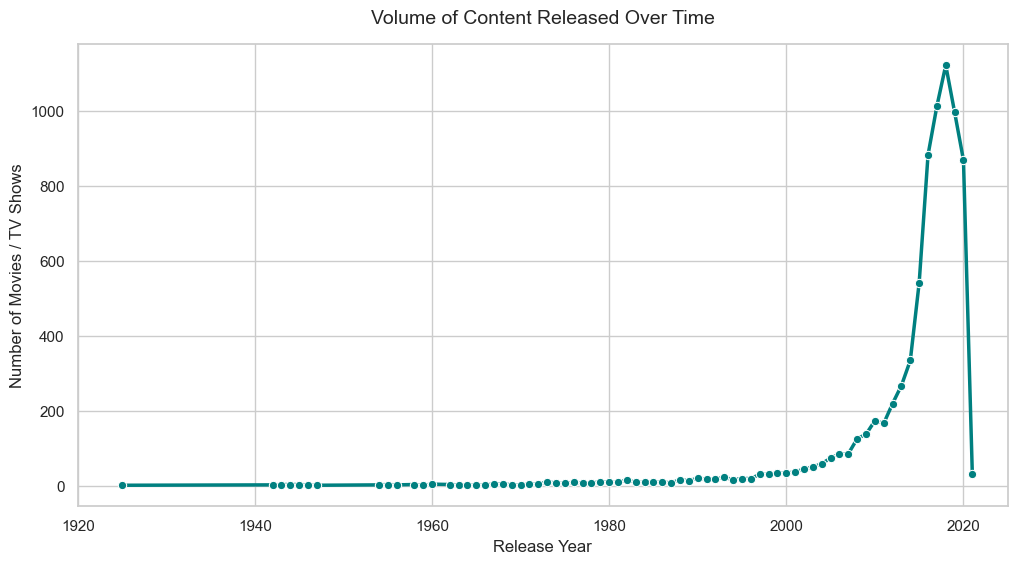

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count releases per year and sort by year chronologically
releases_per_year = df["release_year"].value_counts().sort_index()

# Plot the trend over time
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=releases_per_year.index,
    y=releases_per_year.values,
    marker="o",
    linewidth=2.5,
    color="teal",
)

plt.title("Volume of Content Released Over Time", fontsize=14, pad=15)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Number of Movies / TV Shows", fontsize=12)

plt.xlim(1920, 2025)

plt.show()

### Data Quality insights
- Director Column has most Null value which is about 30% of the total content of the column, also cast and country columns have null values
- I filled the null rows with "unknown" which shows that data is not provided
- In duration column for TV shows data exists in Seasons while for Movies it exists in Minutes, as they both exist in same column so we can not concluded how much time duration TV shows have in minutes which make duration column inconsistent
- 1 movie with 10 min of total duration was identified as outlier, but i check that was correct duration as though it was a documentary 

### Analytical Conclusions
- total contribution of content on Netflix is coming from United state which shows that Netflix's content culture is more inspired from the western culture 
- as the most of the content on Netflix are Movies based they should also make portion for TV show, which might be like 60% for movies and 40% for TV shows, as most of the people nowadays have attention spam issue so hooking them for a large TV show might become difficult

### Limitation of Dataset
- 30% director, 9% cast, and 6% country columns have null/missing value which become total of 45% of total dataset if we drop all of those rows then we've very limited dataset left
- In genre column multiple genre are written as the same time in same column which make hard to decide which show belong to which genre
- also for duration column data is inconsistent which include both season and exact time in same column